
Classification Report:

              precision    recall  f1-score   support

        High       0.97      0.95      0.96        38
         Low       0.92      0.87      0.89        63
      Medium       0.87      0.93      0.90        67

    accuracy                           0.91       168
   macro avg       0.92      0.92      0.92       168
weighted avg       0.91      0.91      0.91       168



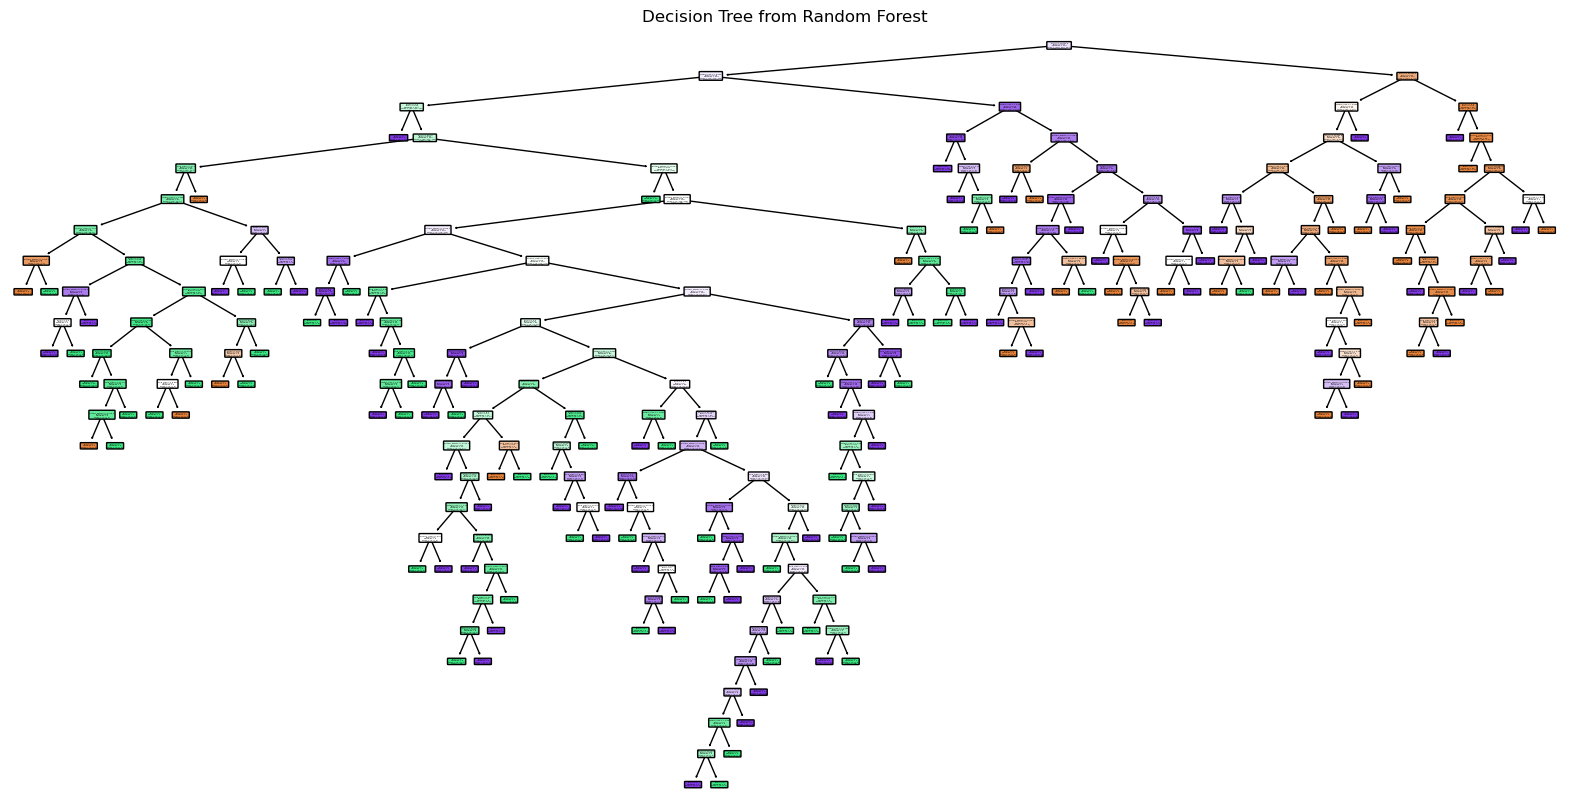

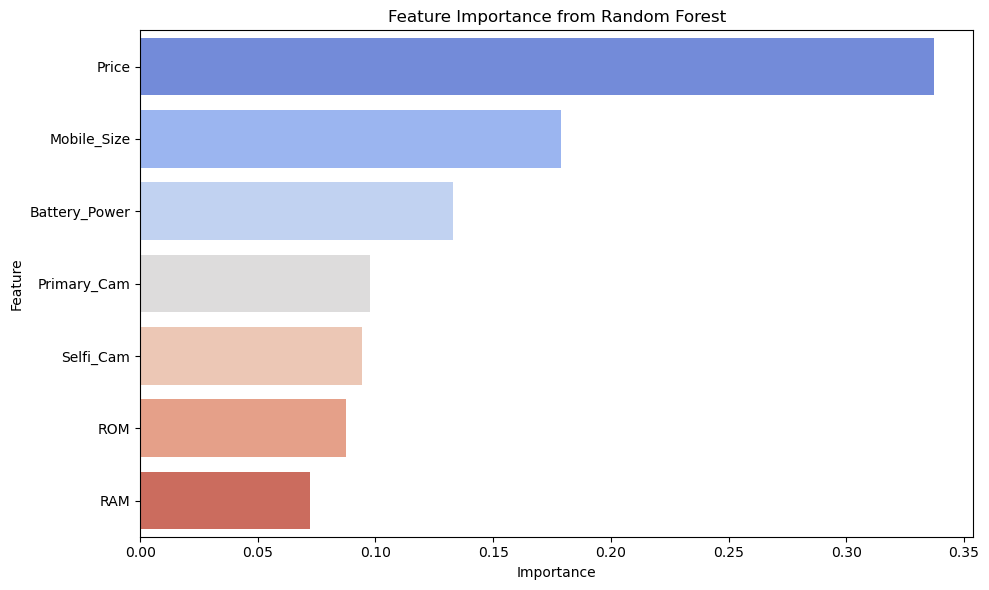

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree
from sklearn.impute import SimpleImputer

# Load Data
df = pd.read_csv("C:/Users/Masterflow techno/Downloads/brand_preference.csv")

# Drop Unnamed column if exists
df = df.drop(columns=["Unnamed: 0"], errors='ignore')

# Create a label based on Ratings (e.g., low <4.0, 4.0–4.4 = medium, >=4.5 = high)
def rating_category(rating):
    if rating < 4.0:
        return "Low"
    elif rating < 4.5:
        return "Medium"
    else:
        return "High"

df["Rating_Category"] = df["Ratings"].apply(rating_category)

# Encode the target variable
label_encoder = LabelEncoder()
df["Rating_Label"] = label_encoder.fit_transform(df["Rating_Category"])

# Features & Target
features = ['RAM', 'ROM', 'Mobile_Size', 'Primary_Cam', 'Selfi_Cam', 'Battery_Power', 'Price']
X = df[features]
y = df["Rating_Label"]

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 1. Visualize a Decision Tree from the Forest
plt.figure(figsize=(20, 10))
plot_tree(model.estimators_[0], 
          feature_names=features, 
          class_names=label_encoder.classes_, 
          filled=True, 
          rounded=True)
plt.title("Decision Tree from Random Forest")
plt.show()

# 2. Feature Importance
importances = model.feature_importances_
feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='coolwarm')
plt.title('Feature Importance from Random Forest')
plt.tight_layout()
plt.show()


In [2]:
# Clean brand names from "Brand me" column
df['Brand'] = df['Brand me'].apply(lambda x: x.split()[0])  # Assumes first word is brand

# Group by Brand and get mean ratings
brand_ratings = df.groupby('Brand')['Ratings'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

print("\nAverage Ratings by Brand:\n")
print(brand_ratings.head(10))  # Top 10 brands by rating



Average Ratings by Brand:

              mean  count
Brand                    
Apple     4.647368     38
Infinix   4.600000      1
OnePlus   4.526316     19
Google    4.500000      4
Motorola  4.500000      1
Realme    4.500000     16
POCO      4.500000     11
Redmi     4.470000     30
Forme     4.450000      2
Samsung   4.415714     70


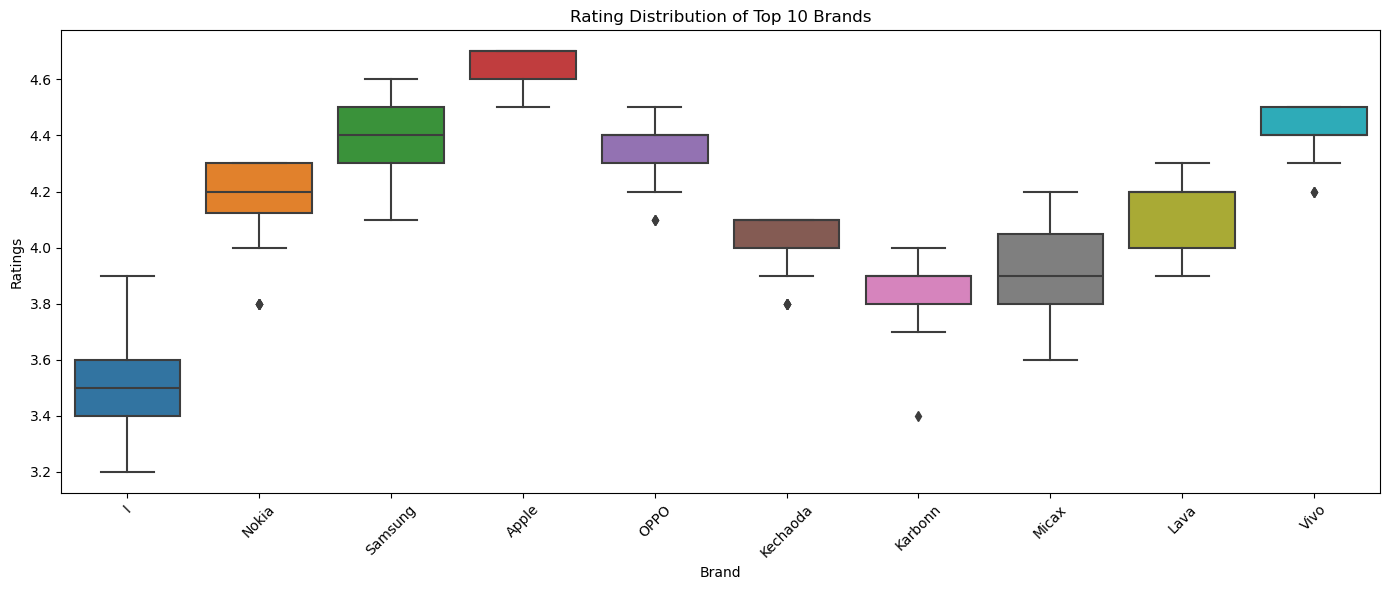

In [3]:
plt.figure(figsize=(14, 6))
top_10_brands = df['Brand'].value_counts().head(10).index
sns.boxplot(data=df[df['Brand'].isin(top_10_brands)], x='Brand', y='Ratings')
plt.title("Rating Distribution of Top 10 Brands")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


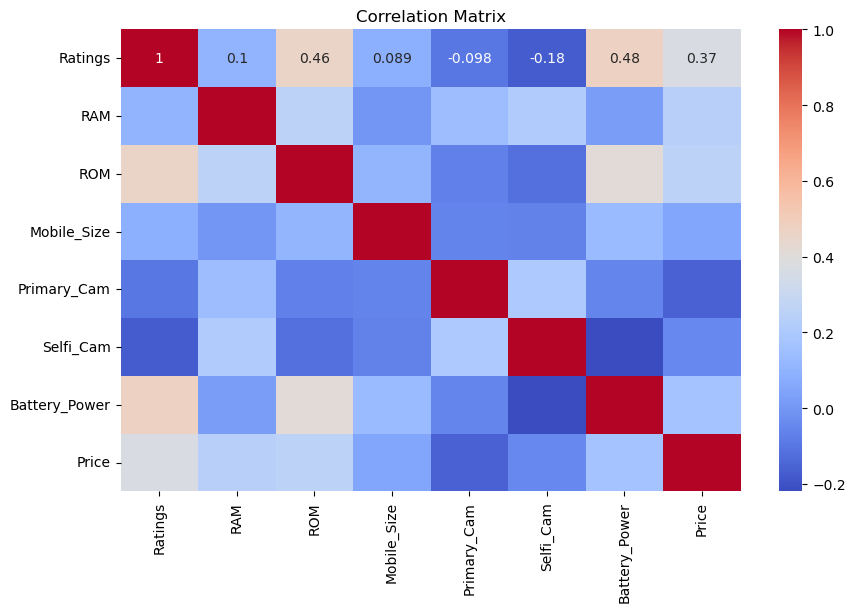

In [4]:
corr = df[['Ratings', 'RAM', 'ROM', 'Mobile_Size', 'Primary_Cam', 'Selfi_Cam', 'Battery_Power', 'Price']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
